# Lab - Boosting
In this lab, we will apply boosting to the California Housing dataset. We will explore:
1. **Adaboost**: boosting by reweighting samples
2. **Gradient boost**: boosting by following gradients of loss (pseudo-residual)

## 1. Introduction & Setup
In this section, we load the [California housing dataset](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html) and perform initial exploration.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Display description of the dataset
#print(housing.DESCR)

## 2. Data preprocessing

In [22]:
# Prepare data for training
from sklearn.model_selection import train_test_split

X = df.drop('MedHouseVal', axis=1) # features
y = df['MedHouseVal'] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 16512
Test set size: 4128


## 3. Adaboost

We will start with the first implementation of boosting **Adaboost**, which focuses on adjusting the weights of misclassified samples and combines weak learners (usually stumps) to improve overall accuracy. 

During model selection, try 4-5 options on `n_estimators`.

In [23]:
# Adaboost
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Test different combinations to find the best model
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators_list = [50, 100, 200, 300, 500]

best_score = -float('inf')
best_params = {}
all_results = []

print("Testing different hyperparameter combinations:\n")
print("-" * 70)

for lr in learning_rates:
    for n_est in n_estimators_list:
        # Train model
        ada_boost = AdaBoostRegressor(n_estimators=n_est, learning_rate=lr, random_state=42)
        ada_boost.fit(X_train, y_train)
        
        # Predict and evaluate
        y_pred = ada_boost.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        all_results.append({
            'learning_rate': lr,
            'n_estimators': n_est,
            'RMSE': rmse,
            'R2': r2
        })
        
        print(f"LR={lr:4.2f}, n_est={n_est:3d} -> RMSE: {rmse:.4f}, R²: {r2:.4f}")
        
        # Track best model
        if r2 > best_score:
            best_score = r2
            best_params = {'learning_rate': lr, 'n_estimators': n_est, 'RMSE': rmse, 'R2': r2}

print("-" * 70)
print(f"\n*** BEST MODEL ***")
print(f"Learning Rate: {best_params['learning_rate']}")
print(f"N Estimators: {best_params['n_estimators']}")
print(f"RMSE: {best_params['RMSE']:.4f}")
print(f"R² Score: {best_params['R2']:.4f}")

# Train final best model
best_ada = AdaBoostRegressor(
    n_estimators=best_params['n_estimators'], 
    learning_rate=best_params['learning_rate'], 
    random_state=42
)
best_ada.fit(X_train, y_train)
y_pred_ada = best_ada.predict(X_test)

ada_rmse = best_params['RMSE']
ada_r2 = best_params['R2']

Testing different hyperparameter combinations:

----------------------------------------------------------------------
LR=0.01, n_est= 50 -> RMSE: 0.7835, R²: 0.5315
LR=0.01, n_est=100 -> RMSE: 0.7737, R²: 0.5432
LR=0.01, n_est=200 -> RMSE: 0.7608, R²: 0.5582
LR=0.01, n_est=300 -> RMSE: 0.7532, R²: 0.5671
LR=0.01, n_est=500 -> RMSE: 0.7524, R²: 0.5680
LR=0.10, n_est= 50 -> RMSE: 0.7525, R²: 0.5678
LR=0.10, n_est=100 -> RMSE: 0.7538, R²: 0.5664
LR=0.10, n_est=200 -> RMSE: 0.7888, R²: 0.5252
LR=0.10, n_est=300 -> RMSE: 0.7909, R²: 0.5226
LR=0.10, n_est=500 -> RMSE: 0.7909, R²: 0.5226
LR=0.50, n_est= 50 -> RMSE: 0.8243, R²: 0.4815
LR=0.50, n_est=100 -> RMSE: 0.8820, R²: 0.4063
LR=0.50, n_est=200 -> RMSE: 0.8820, R²: 0.4063
LR=0.50, n_est=300 -> RMSE: 0.8820, R²: 0.4063
LR=0.50, n_est=500 -> RMSE: 0.8820, R²: 0.4063
LR=1.00, n_est= 50 -> RMSE: 0.7839, R²: 0.5311
LR=1.00, n_est=100 -> RMSE: 0.7839, R²: 0.5311
LR=1.00, n_est=200 -> RMSE: 0.7839, R²: 0.5311
LR=1.00, n_est=300 -> RMSE: 0.7839,

## 4. Gradient boost

**Gradient Boost** establishes strong models by iteratively adding decision trees, where each tree is trained to correct the errors (residuals) of the previous one.

During model selection, try 2-3 options on `max_depth`, `n_estimators` and `min_samples_split` respectively.

In [ ]:
# Gradient boost - Hyperparameter search with visualization
from sklearn.ensemble import GradientBoostingRegressor

# Hyperparameter options to test
max_depths       = [3, 5, 7, 9, 11]
n_estimators_gb  = [100, 200, 300, 400, 500]
min_samples_gb   = [2, 5, 10,]

results_gb = []

print("Testing Gradient Boosting hyperparameters...\n")

for md in max_depths:
    for n_est in n_estimators_gb:
        for mss in min_samples_gb:
            model = GradientBoostingRegressor(
                max_depth=md, n_estimators=n_est,
                min_samples_split=mss, learning_rate=0.1, random_state=42
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            results_gb.append({
                'max_depth': md,
                'n_estimators': n_est,
                'min_samples_split': mss,
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R2': r2_score(y_test, y_pred)
            })

results_gb_df = pd.DataFrame(results_gb)

# --- Best model ---
best_idx = results_gb_df['R2'].idxmax()
best_row = results_gb_df.loc[best_idx]
print(f"Best: max_depth={int(best_row.max_depth)}, n_estimators={int(best_row.n_estimators)}, "
      f"min_samples_split={int(best_row.min_samples_split)}")
print(f"RMSE: {best_row.RMSE:.4f}  |  R²: {best_row.R2:.4f}")

# Train final best model
gb_regressor = GradientBoostingRegressor(
    max_depth=int(best_row.max_depth),
    n_estimators=int(best_row.n_estimators),
    min_samples_split=int(best_row.min_samples_split),
    learning_rate=0.1, random_state=42
)
gb_regressor.fit(X_train, y_train)
y_pred_gb = gb_regressor.predict(X_test)
gb_rmse = best_row.RMSE
gb_r2   = best_row.R2

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gradient Boosting - Hyperparameter Search (R² Score)', fontsize=14)

for ax, md in zip(axes, max_depths):
    subset = results_gb_df[results_gb_df['max_depth'] == md]
    pivot = subset.pivot(index='n_estimators', columns='min_samples_split', values='R2')
    im = ax.imshow(pivot, cmap='RdYlGn', aspect='auto', vmin=results_gb_df.R2.min(), vmax=results_gb_df.R2.max())
    ax.set_xticks(range(len(min_samples_gb)))
    ax.set_xticklabels(min_samples_gb)
    ax.set_yticks(range(len(n_estimators_gb)))
    ax.set_yticklabels(n_estimators_gb)
    ax.set_xlabel('min_samples_split')
    ax.set_ylabel('n_estimators')
    ax.set_title(f'max_depth = {md}')
    # Annotate cells with R² values
    for i in range(len(n_estimators_gb)):
        for j in range(len(min_samples_gb)):
            ax.text(j, i, f"{pivot.iloc[i, j]:.3f}", ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=axes[-1], label='R² Score')
plt.tight_layout()
plt.show()

## 5. Evaluation

Compare the results of adaboost and gradient boost

MODEL COMPARISON
            Model     RMSE  R² Score
         AdaBoost 0.752361  0.568038
Gradient Boosting 0.624524  0.702360

Best performing model: Gradient Boosting


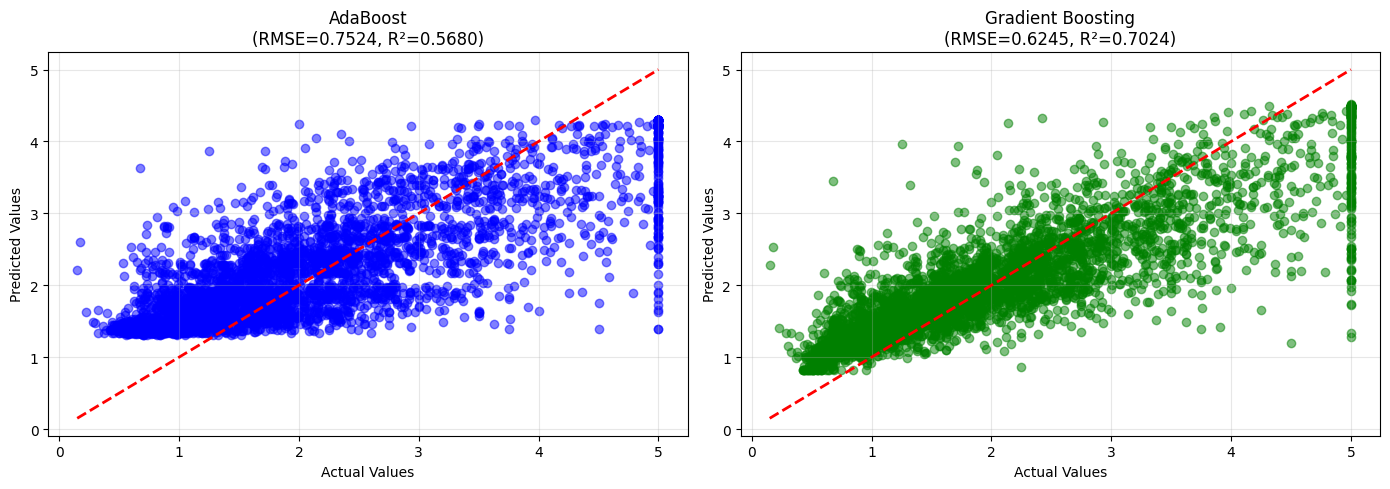

In [31]:
# Evaluation
import pandas as pd

# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting'],
    'RMSE': [ada_rmse, gb_rmse],
    'R² Score': [ada_r2, gb_r2]
})

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(results.to_string(index=False))
print("=" * 50)

# Determine the better model
better_model = 'Gradient Boosting' if gb_r2 > ada_r2 else 'AdaBoost'
print(f"\nBest performing model: {better_model}")

# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AdaBoost
axes[0].scatter(y_test, y_pred_ada, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'AdaBoost\n(RMSE={ada_rmse:.4f}, R²={ada_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Gradient Boosting
axes[1].scatter(y_test, y_pred_gb, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title(f'Gradient Boosting\n(RMSE={gb_rmse:.4f}, R²={gb_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()